In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import os
import pandas as pd
import cv2
import tensorflow


In [21]:
DIR = os.listdir('C:\ACML\Radiography')
print(DIR)

['test', 'train', 'val']


In [22]:
train_folder = r"C:\ACML\Radiography\train"
val_folder = r"C:\ACML\Radiography\val"
test_folder = r"C:\ACML\Radiography\test"

In [23]:
labels = ["NORMAL", "PNEUMONIA"] # each folder has two sub folder name "PNEUMONIA", "NORMAL"
IMG_SIZE = 152 # resize image I will make this 152 when doing preprocessing

def get_data_train(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label) #look for subfolders N and P
        class_num = labels.index(label) #0 for NORMAL, 1 for PNEUMONIA
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)#convert to grayscale
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))#have to make this 152
                data.append([new_array, class_num])
            except Exception as e:
                print(e)
    return np.array(data)

In [24]:
train = get_data_train(train_folder)
test = get_data_train(test_folder)
val = get_data_train(val_folder)

c:\Users\27722\anaconda3\lib\site-packages\ipykernel_launcher.py:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  app.launch_new_instance()


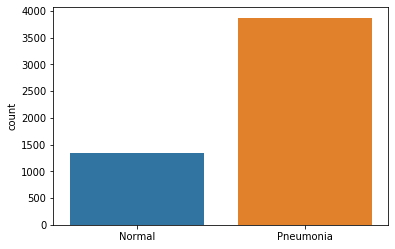

In [25]:
#need to check how many images in each class
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("Pneumonia")
        
sns.countplot(x = l) #specifically state which axis data belongs to
plt.show()

In [26]:
#currently our data is in pairs [immage_data, label_number] but for training
#requre images X and answers y to be separate
#This is feature label separation
#After this X will have all images and y will have label(0 or 1)
X_train = []
y_train = []

X_val = []
y_val = []

X_test = []
y_test = []

for feature, label in train:
    X_train.append(feature)
    y_train.append(label)

for feature, label in test:
    X_test.append(feature)
    y_test.append(label)
    
for feature, label in val:
    X_val.append(feature)
    y_val.append(label)

In [27]:
#Normalization - scale numeric data to be between 0 or 1
#We are working with pixels, so between 0 to 255
X_train = np.array(X_train) / 255.0
X_val = np.array(X_val) / 255.0
X_test = np.array(X_test) / 255.0

In [28]:
X_train.shape
#shows number images in dataset, height and width of each

(5216, 152, 152)

In [29]:
#reshape since CNNs expect a 4D tensor. Add a "Channel" at the end
#to know of image is in color(3) or grayscale(1)
#even make the labels 4D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)#-1 shortcut telling NumPy to figure out number of images automatically
y_train = np.array(y_train)


# This creates a 'strategy' for transforming images during training
datagen = ImageDataGenerator(
    rotation_range=20,      # Randomly rotate images (0-20 degrees)
    zoom_range=0.2,         # Randomly zoom in/out by 20%
    width_shift_range=0.1,  # Randomly shift images horizontally
    height_shift_range=0.1, # Randomly shift images vertically
    horizontal_flip=True,   # Randomly flip images (Normal lungs vs Pneumonia)
    fill_mode='nearest'     # How to fill empty pixels created by rotation/shifts
)

X_val = X_val.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_val = np.array(y_val)

X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_test = np.array(y_test)


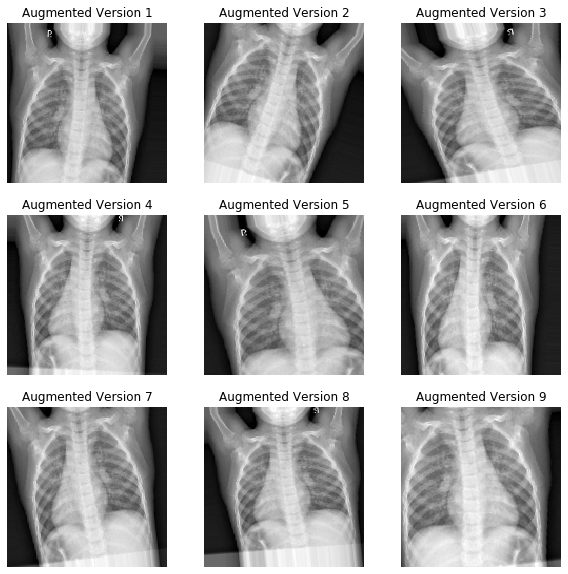

In [30]:
plt.figure(figsize=(10, 10))
# Take one image from your training set
sample_img = X_train[0].reshape((1, IMG_SIZE, IMG_SIZE, 1))

# Generate 9 random versions of this one image
i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch[0].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f"Augmented Version {i+1}")
    plt.axis('off')
    i += 1
    if i % 9 == 0:
        break
plt.show()